# Notebook 2: Exploratory Data Analysis 
- Analyze class distributions and dataset statistics
- Visualize sample images for each class
- Demonstrate example data augmentations
- Define Dataset and DataLoader without augmentation for validation

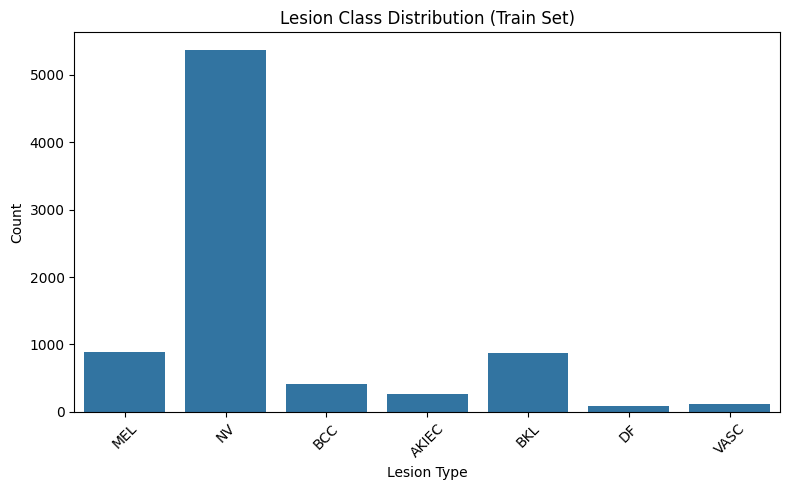

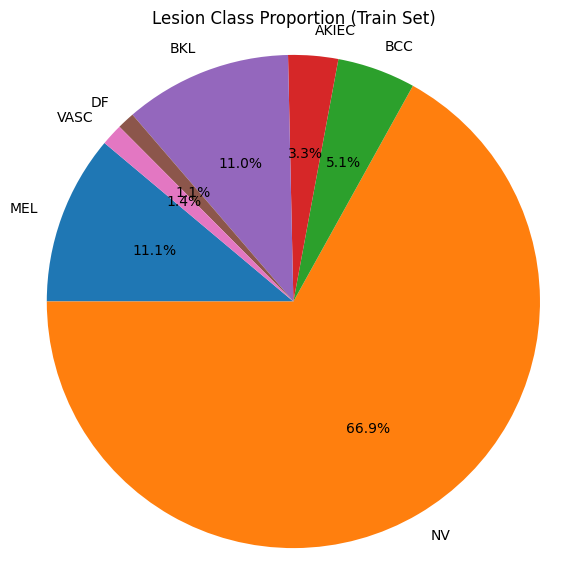

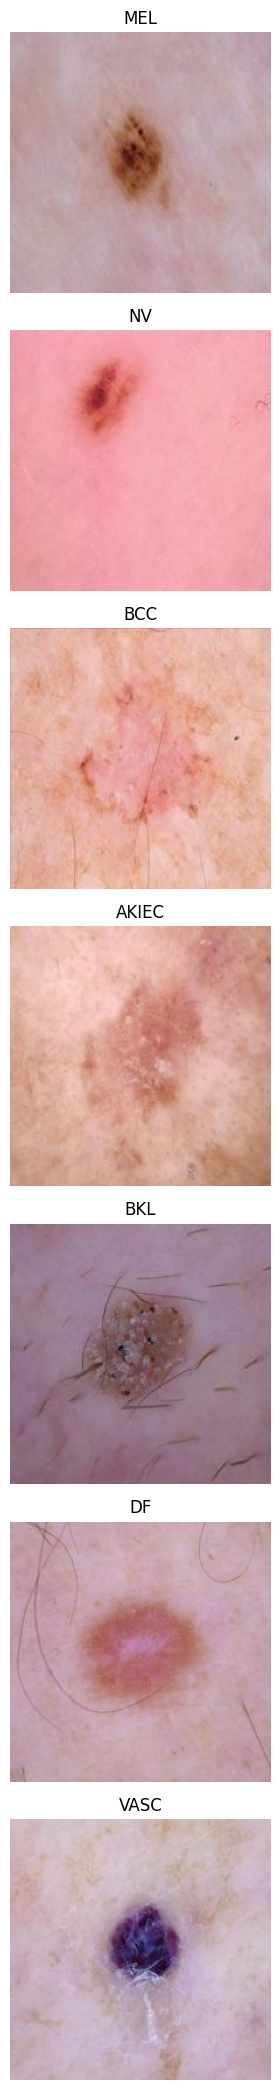

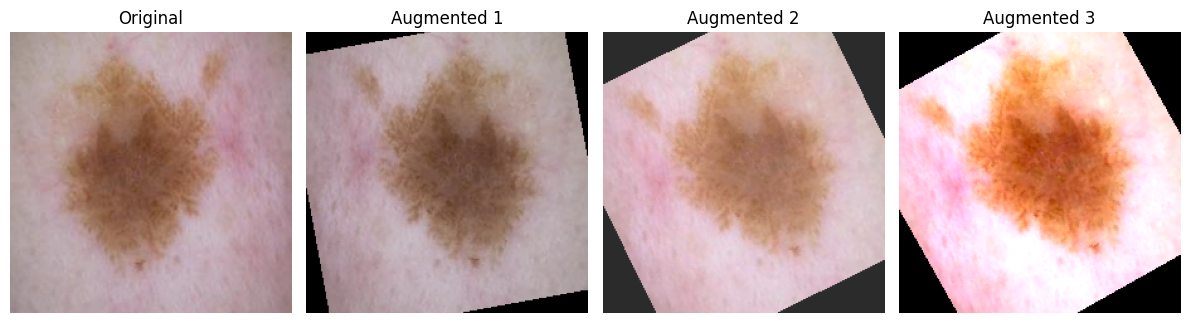

Sample shape: torch.Size([3, 224, 224]), Label index: 1, Class name: NV


In [ ]:
# Import libraries 
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms

# Define the skin lesion class labels and mapping between indices and names
class_columns = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
idx_to_class = {i: c for i, c in enumerate(class_columns)}
class_to_idx = {c: i for i, c in enumerate(class_columns)}

# Load processed CSV files that contain image paths and label indices
train_df = pd.read_csv("train_df_processed.csv")
val_df = pd.read_csv("val_df_processed.csv")

# Plot bar chart showing number of samples for each class in the training set
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='label_idx', order=sorted(train_df['label_idx'].unique()))
plt.title("Lesion Class Distribution (Train Set)")
plt.xticks(ticks=range(len(class_columns)), labels=[idx_to_class[i] for i in range(len(class_columns))], rotation=45)
plt.xlabel("Lesion Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Plot pie chart showing class proportions in the training set
class_counts = train_df['label_idx'].value_counts().sort_index()
plt.figure(figsize=(7, 7))
plt.pie(class_counts, labels=[idx_to_class[i] for i in class_counts.index], autopct='%1.1f%%', startangle=140)
plt.title("Lesion Class Proportion (Train Set)")
plt.axis("equal")
plt.show()

# Function to show one example image for each class from the training set
def show_class_samples(df, image_col='image_path', label_col='label_idx', n=1):
    plt.figure(figsize=(15, 3 * len(class_columns)))
    for idx in range(len(class_columns)):
        sample = df[df[label_col] == idx].sample(n)
        for i, row in enumerate(sample.itertuples()):
            img = Image.open(getattr(row, image_col))
            plt.subplot(len(class_columns), n, idx * n + i + 1)
            plt.imshow(img)
            plt.title(idx_to_class[idx])
            plt.axis("off")
    plt.tight_layout()
    plt.show()

# Display one image per lesion class
show_class_samples(train_df)

# Show how augmentations affect an image using random transformations
sample_row = train_df.sample(1).iloc[0]
img = Image.open(sample_row['image_path'])

augment = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4)
])

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

# Generate and display three augmented versions of the same image from above
for i in range(3):
    augmented_img = augment(img)
    plt.subplot(1, 4, i + 2)
    plt.imshow(augmented_img)
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Custom PyTorch dataset class for loading skin lesion images and labels
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['label_idx']
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Define image preprocessing (resize, normalize) for model input
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

# Create dataset and dataloader objects for training and validation
train_dataset = SkinLesionDataset(train_df, transform=image_transforms)
val_dataset = SkinLesionDataset(val_df, transform=image_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Show the shape and label of one sample to verify dataset loading works
img, label = train_dataset[0]
print(f"Sample shape: {img.shape}, Label index: {label}, Class name: {idx_to_class[label]}")
